### Predict Customer Account Balance with Regression
##### Bank Marketing Dataset: https://www.kaggle.com/datasets/sushant097/bank-marketing-dataset-full 

In [2]:
# Install if needed:
# pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import kagglehub

In [3]:
# ==========================================
# 1. LOAD DATA
# ==========================================
# Change path to your CSV file

path = kagglehub.dataset_download("sushant097/bank-marketing-dataset-full")
df = pd.read_csv(f"{path}/bank-full.csv", sep=";")

print(df.tail(2))
print(df.shape)

       age           job  marital  education default  balance housing loan  \
45209   57   blue-collar  married  secondary      no      668      no   no   
45210   37  entrepreneur  married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pdays  previous poutcome   y  
45209  telephone   17   nov       508         4     -1         0  unknown  no  
45210   cellular   17   nov       361         2    188        11    other  no  
(45211, 17)


In [4]:
# ==========================================
# 2. BASIC INFO
# ==========================================

print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB
None
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000

In [5]:
# ==========================================
# 3. TARGET VARIABLE
# ==========================================

target = "balance"

# Remove leakage / unnecessary columns
# You may keep some if desired
X = df.drop(columns=[target])
y = df[target]

In [6]:
# ==========================================
# 4. FEATURE TYPES
# ==========================================

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", numeric_cols)

Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
Numeric: ['age', 'day', 'duration', 'campaign', 'pdays', 'previous']


C:\Users\vivek\AppData\Local\Temp\ipykernel_17156\3594956691.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [7]:
# ==========================================
# 5. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [9]:
# ==========================================
# 6. PREPROCESSING
# ==========================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [10]:
# ==========================================
# 7. MODEL PIPELINE
# ==========================================

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])


In [11]:
# ==========================================
# 8. TRAIN MODEL
# ==========================================

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [12]:
# ==========================================
# 9. PREDICT
# ==========================================

y_pred = model.predict(X_test)

In [13]:
# ==========================================
# 10. EVALUATE
# ==========================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 4))


===== MODEL PERFORMANCE =====
MAE : 1498.6
RMSE: 3110.61
R2  : 0.0123


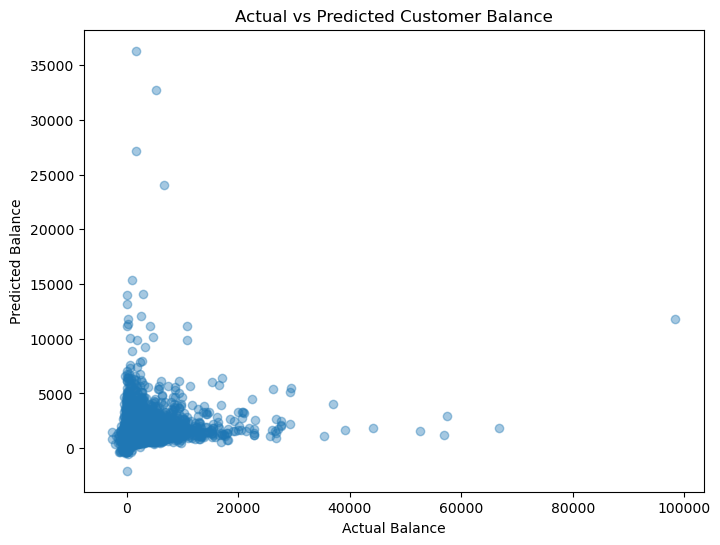

In [14]:
# ==========================================
# 11. ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Balance")
plt.ylabel("Predicted Balance")
plt.title("Actual vs Predicted Customer Balance")
plt.show()

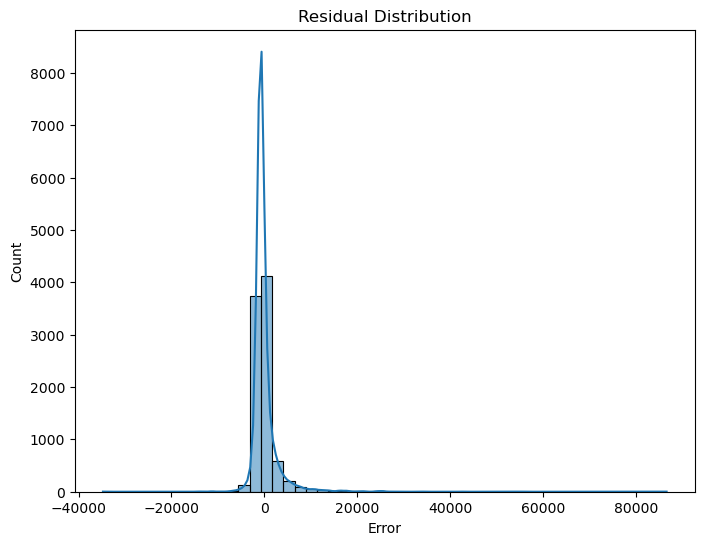

In [15]:
# ==========================================
# 12. RESIDUALS
# ==========================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))
sns.histplot(residuals, bins=50, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

In [17]:
# ==========================================
# 13. SAMPLE PREDICTIONS
# ==========================================

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(results.head(15))

    Actual    Predicted
0      580  1111.045364
1     3644  1669.988681
2      538  1548.657122
3     1773  1912.281587
4      217   761.133889
5     1134   907.143550
6     1085   404.314401
7      127  1190.218641
8        3   625.686453
9      258   929.491108
10     498  1082.558769
11      65   833.174007
12      18   816.126450
13     883  1774.038198
14     640  1359.647429


In [18]:
# ==========================================
# 14. SAVE MODEL (optional)
# ==========================================
# import joblib
# joblib.dump(model, "bank_balance_model.pkl")

In [19]:
# ==========================================================
# IMPROVED VERSION: Better Balance Prediction
# Uses log-transform + XGBoost (or fallback HistGradientBoosting)
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [20]:
# 2. CLEAN / OPTIONAL OUTLIER CAP
# Extreme balances can hurt performance
# ----------------------------------------------------------
low = df["balance"].quantile(0.01)
high = df["balance"].quantile(0.99)
df["balance_capped"] = df["balance"].clip(lower=low, upper=high)

In [21]:
# Use capped target
target = "balance_capped"

In [22]:
# ----------------------------------------------------------
# 3. FEATURE ENGINEERING
# ----------------------------------------------------------
# Duration is often highly predictive (if allowed in your project)
# If you want realistic pre-call prediction, remove duration.
# Here we keep it.

df["has_loan"] = ((df["loan"] == "yes") | (df["housing"] == "yes")).astype(int)
df["contacted_before"] = (df["previous"] > 0).astype(int)
df["campaign_intensity"] = df["campaign"] / (df["previous"] + 1)

# cyclical month encoding
month_map = {
    "jan":1,"feb":2,"mar":3,"apr":4,"may":5,"jun":6,
    "jul":7,"aug":8,"sep":9,"oct":10,"nov":11,"dec":12
}
df["month_num"] = df["month"].map(month_map)
df["month_sin"] = np.sin(2*np.pi*df["month_num"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month_num"]/12)

In [23]:
# ----------------------------------------------------------
# 4. X / y
# Log transform target improves skewed balances
# ----------------------------------------------------------
X = df.drop(columns=["balance", "balance_capped"])
y = np.log1p(df[target])   # log(1 + balance)

# remove negatives before log if needed
y = np.log1p(df[target] - df[target].min() + 1)

c:\Users\vivek\anaconda3\envs\ds_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\vivek\anaconda3\envs\ds_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [24]:
# ----------------------------------------------------------
# 5. SPLIT
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
# ----------------------------------------------------------
# 6. PREPROCESS
# ----------------------------------------------------------
cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])


C:\Users\vivek\AppData\Local\Temp\ipykernel_17156\2856243812.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns.tolist()


In [26]:
# ----------------------------------------------------------
# 7. MODEL (XGBoost if installed, else fallback)
# ----------------------------------------------------------
try:
    from xgboost import XGBRegressor

    reg = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

except:
    from sklearn.ensemble import HistGradientBoostingRegressor

    reg = HistGradientBoostingRegressor(
        max_iter=400,
        learning_rate=0.05,
        max_depth=8,
        random_state=42
    )

model = Pipeline([
    ("prep", preprocessor),
    ("model", reg)
])

In [27]:
# ----------------------------------------------------------
# 8. TRAIN
# ----------------------------------------------------------
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [28]:
# ----------------------------------------------------------
# 9. PREDICT
# Reverse log transform
# ----------------------------------------------------------
pred_log = model.predict(X_test)

# invert target shift
min_target = df[target].min()

y_test_real = np.expm1(y_test) + min_target - 1
pred_real = np.expm1(pred_log) + min_target - 1

In [29]:
# ----------------------------------------------------------
# 10. EVALUATE
# ----------------------------------------------------------
mae = mean_absolute_error(y_test_real, pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, pred_real))
r2 = r2_score(y_test_real, pred_real)

print("\n===== IMPROVED MODEL PERFORMANCE =====")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2  :", round(r2,4))


===== IMPROVED MODEL PERFORMANCE =====
MAE : 1149.78
RMSE: 2259.42
R2  : -0.0103


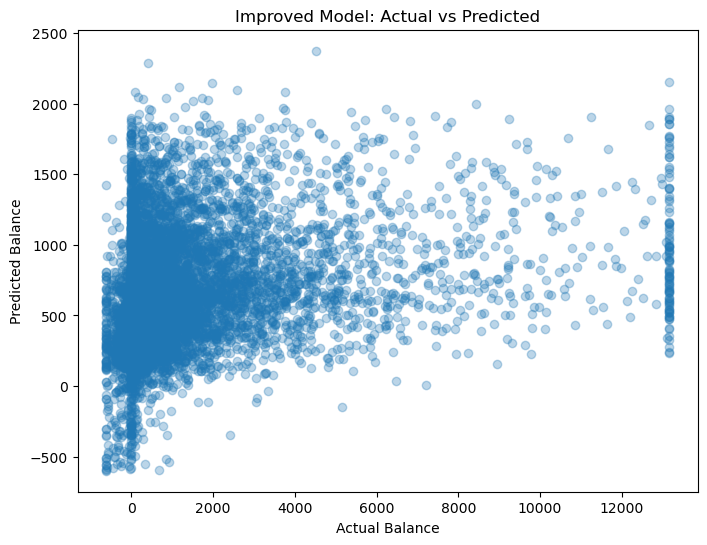

In [30]:
# ----------------------------------------------------------
# 11. PLOT
# ----------------------------------------------------------
plt.figure(figsize=(8,6))
plt.scatter(y_test_real, pred_real, alpha=0.3)
plt.xlabel("Actual Balance")
plt.ylabel("Predicted Balance")
plt.title("Improved Model: Actual vs Predicted")
plt.show()


In [32]:
# ----------------------------------------------------------
# 12. TOP SAMPLE RESULTS
# ----------------------------------------------------------
results = pd.DataFrame({
    "Actual": y_test_real,
    "Predicted": pred_real
}).round(2)

print(results.head(20))

       Actual  Predicted
3776    580.0     573.81
9928   3644.0     794.70
33409   538.0     768.58
31885  1773.0     896.99
15738   217.0     163.03
30813  1134.0     482.87
35463  1085.0     188.68
31382   127.0     659.09
16904     3.0     256.53
11930   258.0     449.46
34145   498.0     786.07
37828    65.0     369.86
1866     18.0     398.23
31271   883.0     789.65
30574   640.0     676.78
41828   536.0    1227.36
37181   247.0     223.34
39042   518.0     791.98
5548      0.0     518.20
34197  5437.0    1291.77
